In [1]:
# ============================================================
# Cell 1: 初始化 — 路径配置（新目录结构）
# ============================================================
setwd("/home/ailab/caohao/AdaDiss/")

suppressPackageStartupMessages({
    library(Seurat)
    library(harmony)
    library(dplyr)
    library(ggplot2)
    library(Matrix)
})

# ── 目录结构 ─────────────────────────────────────────────────
# data/raw/scrna/GSE264393_RAW/   健康肾脏 snRNA-seq
# data/raw/xenium/GSE264334_RAW/  IgAN Xenium
# data/cache/scrna/               R 中间产物
# data/cache/xenium/              R 中间产物
# data/cache/export/              Python numpy 导出
# data/cache/graph/               PyG 图对象
# results/models|predictions|evaluation/
# figures/

PATHS <- list(
    raw = list(
        scrna_dir    = "data/raw/scrna/GSE264393_RAW/",
        xenium_dir   = "data/raw/xenium/GSE264334_RAW/",
        xenium_tx    = "data/raw/xenium/GSE264334_RAW/transcripts.csv.gz",
        xenium_cells = "data/raw/xenium/GSE264334_RAW/cells.csv.gz"
    ),
    cache = list(
        scrna_clustered = "data/cache/scrna/scrna_clustered.rds",
        scrna_markers   = "data/cache/scrna/scrna_markers.rds",
        scrna_annotated = "data/cache/scrna/scrna_annotated.rds",
        xenium_base     = "data/cache/xenium/xenium_base.rds",
        xenium_labeled  = "data/cache/xenium/xenium_labeled.rds"
    ),
    results = list(
        models      = "results/models/",
        predictions = "results/predictions/",
        evaluation  = "results/evaluation/"
    ),
    figures = "figures/"
)

# 创建所有目录
for (d in c(
    "data/cache/scrna", "data/cache/xenium",
    "data/cache/export", "data/cache/graph",
    "results/models", "results/predictions", "results/evaluation",
    "figures"
)) {
    dir.create(d, showWarnings = FALSE, recursive = TRUE)
}

params <- list(
    min_features  = 500,
    max_features  = 6000,
    max_counts    = 25000,
    max_mt_pct    = 25,
    n_pcs         = 30,
    cluster_res   = 0.5,
    harmony_theta = 2
)
SAMPLES <- c("A1", "C3", "C4", "C5")

# 缓存状态一览
cat("=== 缓存状态 ===\n")
for (nm in names(PATHS$cache)) {
    f    <- PATHS$cache[[nm]]
    ex   <- file.exists(f)
    size <- if (ex) paste0(round(file.size(f)/1e6, 1), " MB") else "-"
    cat(sprintf("  %-20s %s  %s\n", nm,
                if (ex) "[HIT]" else "[MISS]", size))
}
cat("\n")


=== 缓存状态 ===
  scrna_clustered      [HIT]  1224.5 MB
  scrna_markers        [HIT]  0.1 MB
  scrna_annotated      [HIT]  1224.5 MB
  xenium_base          [HIT]  3.1 MB
  xenium_labeled       [MISS]  -



[Cache HIT] 加载已注释 scRNA 对象...
  细胞数 : 79826 
  细胞类型: DCT, ENDO, IC-A, IC-B, LEU, LOH, MES, PC, PCT, POD, TAL 


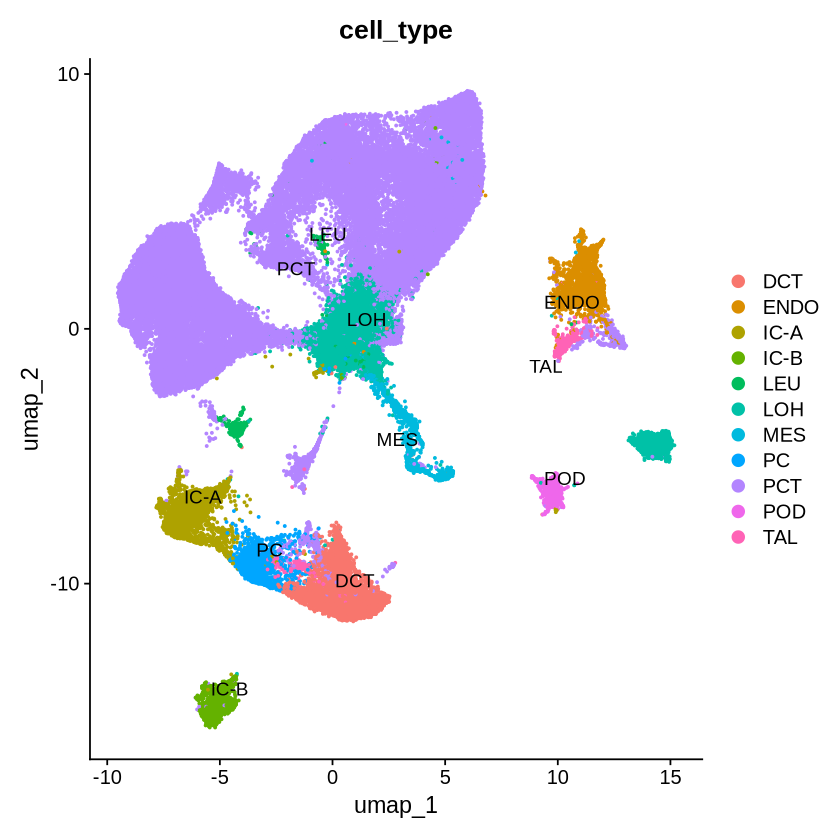

In [2]:
# ============================================================
# Cell 2: scRNA 加载、QC、降维、聚类
# ============================================================

if (file.exists(PATHS$cache$scrna_annotated)) {
    cat("[Cache HIT] 加载已注释 scRNA 对象...\n")
    scrna_obj <- readRDS(PATHS$cache$scrna_annotated)
    cat("  细胞数 :", ncol(scrna_obj), "\n")
    cat("  细胞类型:", paste(sort(unique(scrna_obj$cell_type)),
                           collapse = ", "), "\n")

} else if (file.exists(PATHS$cache$scrna_clustered)) {
    cat("[Cache HIT] 加载聚类中间缓存（待注释）...\n")
    scrna_obj <- readRDS(PATHS$cache$scrna_clustered)
    cat("  细胞数 :", ncol(scrna_obj), "\n")
    cat("  聚类数 :", length(unique(scrna_obj$seurat_clusters)), "\n")

} else {
    cat("[Cache MISS] 从原始文件构建（约 30-60 分钟）...\n")

    obj_list <- list()
    for (sample in SAMPLES) {
        cat("  加载样本", sample, "...\n")
        tmp <- file.path(tempdir(), sample)
        dir.create(tmp, showWarnings = FALSE)
        for (f in c("barcodes.tsv.gz", "features.tsv.gz", "matrix.mtx.gz")) {
            file.copy(
                file.path(PATHS$raw$scrna_dir, paste0(sample, "_", f)),
                file.path(tmp, f)
            )
        }
        obj <- CreateSeuratObject(
            counts = Read10X(data.dir = tmp),
            project = sample, min.cells = 3, min.features = 200
        )
        obj$sample <- sample
        obj_list[[sample]] <- obj
        cat("    核数:", ncol(obj), "\n")
    }

    scrna_raw <- merge(obj_list[[1]], y = obj_list[-1],
                       add.cell.ids = SAMPLES)
    scrna_raw <- JoinLayers(scrna_raw)   # Seurat v5 必须
    cat("合并后:", ncol(scrna_raw), "核\n")

    scrna_raw[["percent.mt"]] <- PercentageFeatureSet(
        scrna_raw, pattern = "^MT-")
    scrna_filt <- subset(scrna_raw,
        subset = nFeature_RNA > params$min_features &
                 nFeature_RNA < params$max_features &
                 nCount_RNA   < params$max_counts   &
                 percent.mt   < params$max_mt_pct)
    cat("QC 过滤后:", ncol(scrna_filt), "核\n")

    cat("标准化 + PCA...\n")
    scrna_obj <- scrna_filt %>%
        NormalizeData(verbose = FALSE) %>%
        FindVariableFeatures(nfeatures = 3000, verbose = FALSE) %>%
        ScaleData(verbose = FALSE) %>%
        RunPCA(npcs = params$n_pcs, verbose = FALSE)

    cat("Harmony 批次校正...\n")
    scrna_obj <- RunHarmony(scrna_obj,
        group.by.vars = "sample",
        theta = params$harmony_theta, verbose = FALSE)

    cat("UMAP + 聚类 (res=", params$cluster_res, ")...\n")
    scrna_obj <- scrna_obj %>%
        RunUMAP(reduction = "harmony",
                dims = 1:params$n_pcs, verbose = FALSE) %>%
        FindNeighbors(reduction = "harmony",
                      dims = 1:params$n_pcs, verbose = FALSE) %>%
        FindClusters(resolution = params$cluster_res, verbose = FALSE)
    cat("聚类数:", length(unique(scrna_obj$seurat_clusters)), "\n")

    saveRDS(scrna_obj, PATHS$cache$scrna_clustered)
    cat("✅ 聚类缓存已保存:", PATHS$cache$scrna_clustered, "\n")
}

DimPlot(scrna_obj,
    group.by = ifelse("cell_type" %in% colnames(scrna_obj@meta.data),
                      "cell_type", "seurat_clusters"),
    reduction = "umap", label = TRUE, repel = TRUE, pt.size = 0.3)


In [3]:
# ============================================================
# Cell 3: 查看 Marker 基因（仅首次需要，辅助 Cell 4 注释）
# ============================================================

if ("cell_type" %in% colnames(scrna_obj@meta.data)) {
    cat("已有 cell_type 注释，跳过\n")
} else {
    scrna_obj <- JoinLayers(scrna_obj)   # Seurat v5

    if (file.exists(PATHS$cache$scrna_markers)) {
        cat("[Cache HIT] 加载 marker 缓存...\n")
        markers <- readRDS(PATHS$cache$scrna_markers)
        cat("  共", nrow(markers), "个 marker 基因\n")
    } else {
        cat("[Cache MISS] 计算 marker genes（约 10-20 分钟）...\n")
        markers <- FindAllMarkers(
            scrna_obj, only.pos = TRUE,
            min.pct = 0.25, logfc.threshold = 0.25, verbose = FALSE
        )
        if (nrow(markers) > 0) {
            saveRDS(markers, PATHS$cache$scrna_markers)
            cat("✅ marker 缓存已保存:", PATHS$cache$scrna_markers, "\n")
        } else {
            warning("FindAllMarkers 返回空结果")
        }
    }

    if (nrow(markers) > 0) {
        top5 <- markers %>%
            mutate(cluster = as.character(cluster)) %>%
            group_by(cluster) %>%
            slice_max(avg_log2FC, n = 5) %>%
            select(cluster, gene, avg_log2FC, pct.1)
        print(top5, n = Inf)
    }

    kidney_markers <- list(
        PCT   = c("CUBN", "LRP2", "SLC5A2"),
        TAL   = c("SLC12A1", "UMOD", "CLDN16"),
        LOH   = c("CLCNKA", "CLCNKB"),
        DCT   = c("SLC12A3", "TRPM6", "CALB1"),
        PC    = c("AQP2", "AQP3", "FXYD4"),
        `IC-A`= c("SLC4A1", "ATP6V1B1"),
        `IC-B`= c("SLC26A4"),
        ENDO  = c("PECAM1", "FLT1", "NOTCH4"),
        MES   = c("PDGFRB", "CARMN"),
        POD   = c("NPHS1", "NPHS2", "CFH"),
        PEC   = c("PAX8", "CLDN1"),
        LEU   = c("PTPRC", "CD74")
    )
    flat <- unique(unlist(lapply(kidney_markers, head, 2)))
    flat <- flat[flat %in% rownames(scrna_obj)]
    print(DotPlot(scrna_obj, features = flat, group.by = "seurat_clusters") +
          RotatedAxis() +
          ggtitle("Marker Expression — 对照此图填写 Cell 4 的映射"))
}


已有 cell_type 注释，跳过


已有 cell_type 注释，跳过


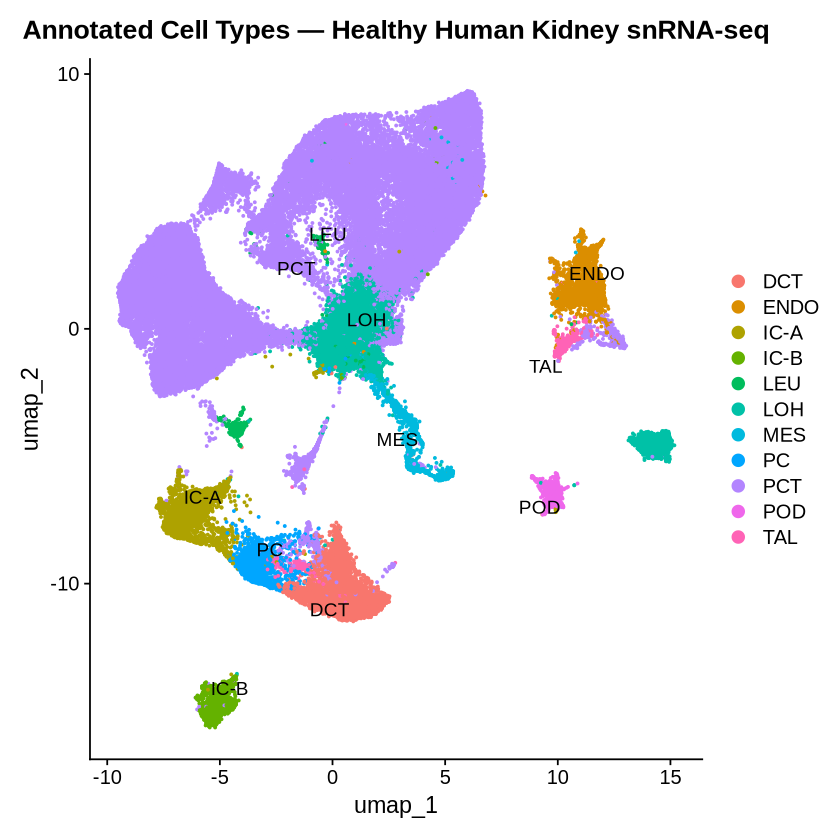

In [4]:
# ============================================================
# Cell 4: 手动注释 cluster → 细胞类型
# ⚠️ 根据 Cell 3 DotPlot 修改 cluster_to_celltype
# ============================================================

if (!"cell_type" %in% colnames(scrna_obj@meta.data)) {

    cluster_to_celltype <- c(
        "0"  = "LOH",
        "1"  = "PCT",
        "2"  = "PCT",
        "3"  = "PCT",
        "4"  = "PCT",
        "5"  = "PCT",
        "6"  = "DCT",
        "7"  = "PCT",
        "8"  = "IC-A",
        "9"  = "ENDO",
        "10" = "PCT",
        "11" = "IC-B",
        "12" = "PC",
        "13" = "MES",
        "14" = "LOH",
        "15" = "PCT",
        "16" = "PCT",
        "17" = "POD",
        "18" = "PCT",
        "19" = "TAL",
        "20" = "PCT",
        "21" = "LEU",
        "22" = "LEU",
        "23" = "TAL",
        "24" = "PCT"
    )

    # unname() 避免 Seurat "No cell overlap" 错误
    scrna_obj$cell_type <- unname(
        cluster_to_celltype[as.character(scrna_obj$seurat_clusters)]
    )

    na_n <- sum(is.na(scrna_obj$cell_type))
    if (na_n > 0) {
        miss <- unique(scrna_obj$seurat_clusters[is.na(scrna_obj$cell_type)])
        warning(na_n, " 个细胞未映射，cluster: ", paste(miss, collapse=", "))
        scrna_obj$cell_type[is.na(scrna_obj$cell_type)] <- "Unknown"
    }

    cat("细胞类型分布：\n")
    print(table(scrna_obj$cell_type))

    saveRDS(scrna_obj, PATHS$cache$scrna_annotated)
    cat("\n✅ 注释缓存已保存:", PATHS$cache$scrna_annotated, "\n")
} else {
    cat("已有 cell_type 注释，跳过\n")
}

DimPlot(scrna_obj, group.by = "cell_type",
    reduction = "umap", label = TRUE, repel = TRUE, pt.size = 0.3) +
    ggtitle("Annotated Cell Types — Healthy Human Kidney snRNA-seq")


In [5]:
# ============================================================
# Cell 5: 加载 Xenium IgAN 肾脏数据
# ============================================================

if (file.exists(PATHS$cache$xenium_labeled)) {
    cat("[Cache HIT] 加载 Xenium 最终缓存（含标签转移）...\n")
    xenium_obj <- readRDS(PATHS$cache$xenium_labeled)
    cat("  细胞数:", ncol(xenium_obj), "\n")
    cat("  标签转移结果分布:\n")
    print(table(xenium_obj$predicted.id))

} else if (file.exists(PATHS$cache$xenium_base)) {
    cat("[Cache HIT] 加载 Xenium 基础缓存（待标签转移）...\n")
    xenium_obj <- readRDS(PATHS$cache$xenium_base)
    cat("  细胞数:", ncol(xenium_obj), "\n")

} else {
    cat("[Cache MISS] 从原始文件加载 Xenium 数据...\n")

    # 修复：Read10X 返回 list 时提取 Gene Expression
    xenium_raw <- Read10X(data.dir = PATHS$raw$xenium_dir)
    if (is.list(xenium_raw)) {
        cat("  检测到多种类型:", paste(names(xenium_raw), collapse=", "), "\n")
        xenium_counts <- if ("Gene Expression" %in% names(xenium_raw))
            xenium_raw[["Gene Expression"]] else xenium_raw[[1]]
    } else {
        xenium_counts <- xenium_raw
    }

    xenium_obj <- CreateSeuratObject(
        counts = xenium_counts, project = "Kidney_IgAN", min.cells = 3
    )
    cat("  细胞数:", ncol(xenium_obj), "\n")
    cat("  基因数:", nrow(xenium_obj), "\n")

    # 修复：直接传路径，R 原生支持读取 .gz
    cells_meta <- read.csv(PATHS$raw$xenium_cells)
    rownames(cells_meta) <- cells_meta$cell_id
    common_cells <- intersect(colnames(xenium_obj), rownames(cells_meta))
    cat("  匹配细胞数:", length(common_cells), "\n")

    xenium_obj <- xenium_obj[, common_cells]
    xenium_obj <- AddMetaData(xenium_obj,
        metadata = cells_meta[common_cells,
            c("x_centroid", "y_centroid", "transcript_counts",
              "cell_area", "nucleus_area")])

    saveRDS(xenium_obj, PATHS$cache$xenium_base)
    cat("✅ Xenium 基础缓存已保存:", PATHS$cache$xenium_base, "\n")
}


[Cache HIT] 加载 Xenium 基础缓存（待标签转移）...
  细胞数: 30802 


In [6]:
# ============================================================
# Cell 6: Seurat 标签转移（定性参考，不参与 GNN 训练）
# 注：Xenium 377 基因面板导致锚点少，k.weight 动态适配
# ============================================================

if (file.exists(PATHS$cache$xenium_labeled) &&
    "predicted.id" %in% colnames(xenium_obj@meta.data)) {
    cat("[Cache HIT] 标签转移结果已存在，跳过\n")

} else {
    cat("[Cache MISS] 运行 Seurat 标签转移...\n")

    common_genes <- intersect(rownames(scrna_obj), rownames(xenium_obj))
    cat("  共同基因数:", length(common_genes), "\n")

    scrna_sub  <- scrna_obj[common_genes, ]
    xenium_sub <- xenium_obj[common_genes, ]
    DefaultAssay(xenium_sub) <- "RNA"

    safe_dims <- 1:min(params$n_pcs, length(common_genes) - 1)
    cat("  使用 dims:", min(safe_dims), "~", max(safe_dims), "\n")

    cat("  寻找锚点...\n")
    anchors <- FindTransferAnchors(
        reference            = scrna_sub,
        query                = xenium_sub,
        normalization.method = "LogNormalize",
        reference.reduction  = "harmony",
        dims                 = safe_dims
    )

    # 动态 k.weight（锚点少时自动降低）
    n_anchors <- nrow(anchors@anchors)
    k_weight  <- min(20, n_anchors - 1)
    cat("  锚点数:", n_anchors, "→ k.weight =", k_weight, "\n")

    cat("  转移标签...\n")
    predictions <- TransferData(
        anchorset = anchors,
        refdata   = scrna_obj$cell_type,
        dims      = safe_dims,
        k.weight  = k_weight
    )
    xenium_obj <- AddMetaData(xenium_obj, metadata = predictions)

    saveRDS(xenium_obj, PATHS$cache$xenium_labeled)
    cat("\n✅ Xenium 标签转移缓存已保存:", PATHS$cache$xenium_labeled, "\n")
}

cat("\nSeurat 标签转移结果分布（定性参考）：\n")
print(table(xenium_obj$predicted.id))


[Cache MISS] 运行 Seurat 标签转移...
  共同基因数: 361 
  使用 dims: 1 ~ 30 
  寻找锚点...


Warning message:
“No layers found matching search pattern provided”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 25 anchors



  锚点数: 25 → k.weight = 20 
  转移标签...


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights



ERROR: Error in FindWeights(object = combined.ob, reduction = weight.reduction, : Number of anchor cells is less than k.weight. Consider lowering k.weight to less than 5 or increase k.anchor.


In [ ]:
# ============================================================
# Cell 7: 完成确认 + 缓存状态汇总
# ============================================================

cat("=== 所有步骤完成 ===\n\n")
cat("缓存文件状态：\n")
for (nm in names(PATHS$cache)) {
    f    <- PATHS$cache[[nm]]
    ex   <- file.exists(f)
    size <- if (ex) paste0(round(file.size(f)/1e6, 1), " MB") else "不存在"
    cat(sprintf("  %-22s %s  (%s)\n", nm, if (ex) "✅" else "❌", size))
}

cat("\n下次运行各 Cell 的耗时（缓存命中）：\n")
cat("  Cell 2: ~5 秒  (scrna_annotated)\n")
cat("  Cell 3: 跳过   (已有 cell_type)\n")
cat("  Cell 4: 跳过   (已有 cell_type)\n")
cat("  Cell 5: ~10 秒 (xenium_labeled)\n")
cat("  Cell 6: 跳过   (xenium_labeled 含标签转移)\n")
cat("\n下一步：运行 train_copy_spot_level_kidney.ipynb\n")
